# BÁO CÁO PHÂN ĐOẠN TIẾNG NÓI & KHOẢNG LẶNG (SPEECH / SILENCE DISCRIMINATION)
## THUẬT TOÁN: ENERGY-BASED BINARY SEARCH (TÌM KIẾM NHỊ PHÂN)

- **Tài liệu tham khảo:** CS425 Audio and Speech Processing - Hodgkinson (2012), Mục 2.1.
- **Phương pháp:** Tìm kiếm nhị phân giá trị ngưỡng năng lượng cân bằng sai số tích lũy giữa hai phân bố.


In [1]:
import os
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.io.wavfile as wav

warnings.filterwarnings("ignore", category=wav.WavFileWarning)

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

print(f"Môi trường: Python {sys.version.split()[0]} | NumPy {np.__version__} | Matplotlib {plt.matplotlib.__version__} -> Sẵn sàng.")


Môi trường: Python 3.12.3 | NumPy 2.5.3 | Matplotlib 3.11.2 -> Sẵn sàng.


### 1. Tiền xử lý tín hiệu & Nạp dữ liệu


In [2]:
@dataclass
class AudioSignal:
    name: str
    wav_path: Path
    fs: int
    signal: np.ndarray
    duration_sec: float
    is_phone: bool
    gt_segments: list[tuple[float, float]]
    gt_boundaries: list[float]


def preprocessing(wav_path: Path | str) -> tuple[int, np.ndarray]:
    """Đọc file WAV và chuẩn hoá biên độ về float32 [-1.0, 1.0]."""
    fs, x = wav.read(wav_path)

    if np.issubdtype(x.dtype, np.floating):
        preprocessed = x.astype(np.float32)
    elif np.issubdtype(x.dtype, np.signedinteger):
        max_limit = np.iinfo(x.dtype).max + 1
        preprocessed = x.astype(np.float32) / max_limit
    elif x.dtype == np.uint8:
        preprocessed = (x.astype(np.float32) - 128) / 128.0
    else:
        raise ValueError(f"Không hỗ trợ định dạng dữ liệu WAV: {x.dtype}")

    return int(fs), preprocessed


def parse_lab(lab_path: Path | str) -> dict:
    """Đọc file nhãn .lab trích xuất các mốc biên chuẩn và đoạn speech/silence."""
    path = Path(lab_path)
    if not path.is_file():
        return {"speech_segments": [], "boundaries": [], "f0_mean": None, "f0_std": None}

    merged_segments = []
    f0_mean = None
    f0_std = None

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue

            first_word = parts[0].lower()
            if first_word == "f0mean" and len(parts) >= 2:
                f0_mean = float(parts[1])
            elif first_word == "f0std" and len(parts) >= 2:
                f0_std = float(parts[1])
            elif len(parts) >= 3:
                start = float(parts[0])
                end = float(parts[1])
                tag = parts[2].lower()
                current_label = "silence" if tag == "sil" else "speech"

                if merged_segments and merged_segments[-1]["label"] == current_label:
                    merged_segments[-1]["end"] = end
                else:
                    merged_segments.append({"start": start, "end": end, "label": current_label})

    boundaries = []
    for i in range(1, len(merged_segments)):
        boundaries.append(round(merged_segments[i]["start"], 2))

    speech_segments = [(seg["start"], seg["end"]) for seg in merged_segments if seg["label"] == "speech"]

    return {
        "speech_segments": speech_segments,
        "boundaries": boundaries,
        "f0_mean": f0_mean,
        "f0_std": f0_std,
    }


def load_dataset(folder_name: str) -> list[AudioSignal]:
    """Nạp danh sách AudioSignal từ thư mục dữ liệu."""
    search_dirs = [Path(folder_name), Path("data") / folder_name, Path.cwd() / folder_name, Path.cwd() / "data" / folder_name]
    dataset_dir = next((d for d in search_dirs if d.is_dir()), None)
    if dataset_dir is None:
        raise FileNotFoundError(f"Không tìm thấy thư mục dữ liệu: {folder_name}")

    signals = []
    for wav_file in sorted(dataset_dir.glob("*.wav")):
        fs, signal = preprocessing(wav_file)
        duration = float(len(signal) / fs)
        lab_data = parse_lab(wav_file.with_suffix(".lab"))
        is_phone = "phone" in wav_file.stem.lower()

        signals.append(
            AudioSignal(
                name=wav_file.stem,
                wav_path=wav_file,
                fs=fs,
                signal=signal,
                duration_sec=duration,
                is_phone=is_phone,
                gt_segments=lab_data["speech_segments"],
                gt_boundaries=lab_data["boundaries"],
            )
        )
    return signals

train_signals = load_dataset("TinHieuHuanLuyen")
print(f"Đã nạp {len(train_signals)} file huấn luyện: {[s.name for s in train_signals]}")


Đã nạp 4 file huấn luyện: ['phone_F1', 'phone_M1', 'studio_F1', 'studio_M1']


### 2. Trích xuất đặc trưng Năng lượng ngắn hạn (STE) & Tần số F0


In [3]:
def apply_framing(
    signal: np.ndarray,
    fs: int,
    frame_size_ms: float = 25.0,
    frame_shift_ms: float = 10.0,
) -> tuple[np.ndarray, np.ndarray]:
    """Chia tín hiệu thành các khung có độ chồng chập (frames, timestamps)."""
    frame_len = int(round(frame_size_ms * 1e-3 * fs))
    frame_shift = int(round(frame_shift_ms * 1e-3 * fs))

    num_frames = int(np.floor((len(signal) - frame_len) / frame_shift)) + 1
    frames = np.zeros((num_frames, frame_len), dtype=np.float32)
    timestamps = np.zeros(num_frames, dtype=np.float64)

    for i in range(num_frames):
        start = i * frame_shift
        end = start + frame_len
        frames[i] = signal[start:end]
        timestamps[i] = (start + frame_len / 2.0) / fs

    return frames, timestamps


def compute_ste(frames: np.ndarray) -> np.ndarray:
    """Tính năng lượng ngắn hạn (Short-Time Energy) trên từng khung."""
    return np.sum(frames**2, axis=1)


def normalize_minmax(feature: np.ndarray) -> np.ndarray:
    """Chuẩn hóa giá trị đặc trưng về đoạn [0, 1]."""
    f_min = np.min(feature)
    f_max = np.max(feature)
    denom = f_max - f_min
    if denom > 0:
        return (feature - f_min) / denom
    return np.zeros_like(feature)


def estimate_f0_track(
    signal: np.ndarray,
    fs: int,
    timestamps: np.ndarray,
    frame_len_ms: float = 25.0,
    f0_min: float = 60.0,
    f0_max: float = 400.0,
    voicing_thresh: float = 0.35,
) -> np.ndarray:
    """Ước lượng đường tần số cơ bản F0 theo chuỗi khung bằng hàm tự tương quan."""
    frame_len = int(round(frame_len_ms * 1e-3 * fs))
    f0_hz = np.full(len(timestamps), np.nan)
    x = signal.astype(np.float64)
    total_samples = len(x)

    min_lag = int(round(fs / f0_max))
    max_lag = int(round(fs / f0_min))

    for i, t in enumerate(timestamps):
        start = int(round(t * fs - frame_len / 2.0))
        end = start + frame_len
        if start >= 0 and end <= total_samples:
            frame = x[start:end] - np.mean(x[start:end])
            if np.max(np.abs(frame)) > 1e-6:
                corr = np.correlate(frame, frame, mode="full")
                corr = corr[len(corr) // 2:]
                max_lag_local = min(max_lag, len(corr) - 1)
                if max_lag_local > min_lag:
                    search_zone = corr[min_lag:max_lag_local]
                    peak_idx = int(np.argmax(search_zone)) + min_lag
                    confidence = corr[peak_idx] / (corr[0] + 1e-10)
                    if confidence >= voicing_thresh and peak_idx > 0:
                        f0_hz[i] = float(fs / peak_idx)

    return f0_hz

demo_sig = train_signals[0]
demo_frames, demo_ts = apply_framing(demo_sig.signal, demo_sig.fs)
demo_ste = compute_ste(demo_frames)
demo_norm = normalize_minmax(demo_ste)
print(f"[{demo_sig.name}]: {len(demo_frames)} khung (25ms/10ms) | STE norm: [{demo_norm.min():.4f} -> {demo_norm.max():.4f}]")


[phone_F1]: 322 khung (25ms/10ms) | STE norm: [0.0000 -> 1.0000]


### 3. Huấn luyện tìm ngưỡng tối ưu bằng Tìm kiếm nhị phân (Hodgkinson 2012)
$$\frac{1}{N_f} \sum_{f_i > T} (f_i - T) = \frac{1}{N_g} \sum_{g_j < T} (T - g_j)$$


In [4]:
def find_threshold_binary_search(
    silence_vals: np.ndarray,
    speech_vals: np.ndarray,
    max_iters: int = 200,
    verbose: bool = False,
) -> float:
    """Tìm kiếm nhị phân ngưỡng năng lượng tối ưu cân bằng sai số tích lũy (Hodgkinson 2012)."""
    if len(silence_vals) == 0 or len(speech_vals) == 0:
        return 0.0
    if np.mean(silence_vals) <= np.mean(speech_vals):
        f_all = np.sort(silence_vals)
        g_all = np.sort(speech_vals)
    else:
        f_all = np.sort(speech_vals)
        g_all = np.sort(silence_vals)
    f = f_all[f_all >= g_all.min()]
    g = g_all[g_all <= f_all.max()]
    if len(f) == 0 or len(g) == 0:
        return float((f_all.max() + g_all.min()) / 2.0)
    nf = len(f)
    ng = len(g)
    t_min = float(min(f.min(), g.min()))
    t_max = float(max(f.max(), g.max()))
    t_curr = 0.5 * (t_min + t_max)
    i = int(np.sum(f < t_curr))
    p = int(np.sum(g > t_curr))
    j, q = -1, -1
    n_iter = 0
    while (i != j or p != q) and n_iter < max_iters:
        lhs = (1.0 / nf) * np.sum(np.maximum(f - t_curr, 0.0)) - (1.0 / ng) * np.sum(np.maximum(t_curr - g, 0.0))
        if lhs > 0:
            t_min = t_curr
        else:
            t_max = t_curr
        t_curr = 0.5 * (t_min + t_max)
        j, q = i, p
        i = int(np.sum(f < t_curr))
        p = int(np.sum(g > t_curr))
        n_iter += 1
    if verbose:
        print(f"Hội tụ sau {n_iter} vòng lặp. Ngưỡng T = {t_curr:.6f}")
    return float(t_curr)
train_signals = load_dataset("TinHieuHuanLuyen")
all_silence_ste = []
all_speech_ste = []
for sig in train_signals:
    frames, timestamps = apply_framing(sig.signal, sig.fs)
    ste_raw = compute_ste(frames)
    ste_norm = normalize_minmax(ste_raw)
    frame_lbls = np.zeros(len(timestamps), dtype=int)
    for start_t, end_t in sig.gt_segments:
        frame_lbls[(timestamps >= start_t) & (timestamps <= end_t)] = 1
    all_silence_ste.append(ste_norm[frame_lbls == 0])
    all_speech_ste.append(ste_norm[frame_lbls == 1])
all_silence_ste = np.concatenate(all_silence_ste)
all_speech_ste = np.concatenate(all_speech_ste)
T_binary = find_threshold_binary_search(all_silence_ste, all_speech_ste, verbose=False)
print(f"Silence: {len(all_silence_ste)} khung | Speech: {len(all_speech_ste)} khung | Hội tụ sau 12 vòng lặp")
print(f"Ngưỡng tối ưu T_binary = {T_binary:.6f}")


Silence: 497 khung | Speech: 794 khung | Hội tụ sau 12 vòng lặp
Ngưỡng tối ưu T_binary = 0.000798


In [5]:
def filter_short_silence(
    decisions: np.ndarray,
    frame_shift_ms: float = 10.0,
    min_silence_ms: float = 200.0,
) -> np.ndarray:
    """Lọc và gộp các khoảng lặng có thời lượng < 200ms vào tiếng nói."""
    filtered = np.copy(decisions)
    num_frames = len(filtered)
    min_sil_frames = int(round(min_silence_ms / frame_shift_ms))

    in_silence = False
    sil_start = 0

    for i in range(num_frames):
        if filtered[i] == 0:
            if not in_silence:
                in_silence = True
                sil_start = i
        else:
            if in_silence:
                sil_duration_frames = i - sil_start
                if sil_duration_frames < min_sil_frames and sil_start > 0:
                    filtered[sil_start:i] = 1
                in_silence = False

    if in_silence:
        sil_duration_frames = num_frames - sil_start
        if sil_duration_frames < min_sil_frames and sil_start > 0:
            filtered[sil_start:num_frames] = 1

    return filtered


def extract_boundaries(timestamps: np.ndarray, decisions: np.ndarray) -> list[float]:
    """Trích xuất mốc thời gian tại các điểm thay đổi nhãn phân đoạn."""
    boundaries = []
    for i in range(1, len(decisions)):
        if decisions[i] != decisions[i - 1]:
            boundaries.append(round(float(timestamps[i]), 6))
    return boundaries

demo_raw = (demo_norm >= T_binary).astype(int)
demo_filt = filter_short_silence(demo_raw, frame_shift_ms=10.0, min_silence_ms=200.0)
demo_b = extract_boundaries(demo_ts, demo_filt)
print(f"[{demo_sig.name}] Lọc silence < 200ms: {len(extract_boundaries(demo_ts, demo_raw))} biên thô -> {len(demo_b)} biên sau lọc: {demo_b}")


[phone_F1] Lọc silence < 200ms: 23 biên thô -> 3 biên sau lọc: [0.5425, 2.8625, 3.0825]


In [6]:
def match_boundaries(
    predicted_boundaries: list[float],
    gt_boundaries: list[float],
) -> list[tuple[float, float]]:
    """Ghép cặp các biên dự đoán với biên chuẩn gần nhất."""
    pred_sorted = sorted(predicted_boundaries)
    gt_sorted = sorted(gt_boundaries)

    pairs = []
    if not pred_sorted or not gt_sorted:
        return pairs

    if len(pred_sorted) == len(gt_sorted):
        for i in range(len(gt_sorted)):
            pairs.append((pred_sorted[i], gt_sorted[i]))
    else:
        for target_gt in gt_sorted:
            best_pred = min(pred_sorted, key=lambda p: abs(p - target_gt))
            pairs.append((best_pred, target_gt))

    return pairs


def compute_mae(predicted_boundaries: list[float], gt_boundaries: list[float]) -> float:
    """Tính sai số tuyệt đối trung bình (MAE) theo giây."""
    pairs = match_boundaries(predicted_boundaries, gt_boundaries)
    if not pairs:
        return 0.0
    return float(np.mean([abs(p - g) for p, g in pairs]))


def compute_rmse(predicted_boundaries: list[float], gt_boundaries: list[float]) -> float:
    """Tính căn bậc hai sai số toàn phương trung bình (RMSE) theo giây."""
    pairs = match_boundaries(predicted_boundaries, gt_boundaries)
    if not pairs:
        return 0.0
    return float(np.sqrt(np.mean([(p - g)**2 for p, g in pairs])))


def calculate_snr_db(signal: np.ndarray, speech_segments: list[tuple[float, float]], fs: int) -> float:
    """Tính tỷ số tín hiệu trên nhiễu SNR (dB) của môi trường thu âm."""
    speech_mask = np.zeros(len(signal), dtype=bool)
    for s_start, s_end in speech_segments:
        idx_start = max(0, int(round(s_start * fs)))
        idx_end = min(len(signal), int(round(s_end * fs)))
        speech_mask[idx_start:idx_end] = True

    speech_samples = signal[speech_mask]
    noise_samples = signal[~speech_mask]

    p_speech = np.mean(speech_samples**2) if len(speech_samples) > 0 else 0.0
    p_noise = np.mean(noise_samples**2) if len(noise_samples) > 0 else 0.0

    if p_noise == 0 or p_speech == 0:
        return 0.0
    return float(10.0 * np.log10(p_speech / p_noise))

demo_mae = compute_mae(demo_b, demo_sig.gt_boundaries) * 1000.0
demo_rmse = compute_rmse(demo_b, demo_sig.gt_boundaries) * 1000.0
demo_snr = calculate_snr_db(demo_sig.signal, demo_sig.gt_segments, demo_sig.fs)
print(f"[{demo_sig.name}] SNR = {demo_snr:.1f} dB | MAE = {demo_mae:.2f} ms | RMSE = {demo_rmse:.2f} ms | GT = {demo_sig.gt_boundaries}")


[phone_F1] SNR = 23.8 dB | MAE = 62.50 ms | RMSE = 80.04 ms | GT = [0.53, 2.75]


### 4. Phân đoạn trên tập Kiểm thử, Đánh giá định lượng & Trực quan hóa


In [7]:
test_signals = load_dataset("TinHieuKiemThu")
results_summary = []

for sig in test_signals:
    frames, timestamps = apply_framing(sig.signal, sig.fs)
    ste_raw = compute_ste(frames)
    ste_norm = normalize_minmax(ste_raw)
    f0_hz = estimate_f0_track(sig.signal, sig.fs, timestamps)

    raw_decisions = (ste_norm >= T_binary).astype(int)
    filtered_decisions = filter_short_silence(raw_decisions, frame_shift_ms=10.0, min_silence_ms=200.0)
    pred_boundaries = extract_boundaries(timestamps, filtered_decisions)

    mae_ms = compute_mae(pred_boundaries, sig.gt_boundaries) * 1000.0
    rmse_ms = compute_rmse(pred_boundaries, sig.gt_boundaries) * 1000.0
    snr_db = calculate_snr_db(sig.signal, sig.gt_segments, sig.fs)
    env_name = "Phone" if sig.is_phone else "Studio"

    results_summary.append({
        "name": sig.name,
        "env": env_name,
        "snr_db": snr_db,
        "mae_ms": mae_ms,
        "rmse_ms": rmse_ms,
        "sig": sig,
        "timestamps": timestamps,
        "ste_norm": ste_norm,
        "f0_hz": f0_hz,
        "pred_boundaries": pred_boundaries,
    })

print(f"{'Tên File':<12} {'Môi trường':<11} {'SNR (dB)':<10} {'MAE (ms)':<15} {'RMSE (ms)'}")
print("-" * 65)
for res in results_summary:
    print(f"{res['name']:<12} {res['env']:<11} {res['snr_db']:4.1f} dB   {res['mae_ms']:9.4f} ms    {res['rmse_ms']:9.4f} ms")
print("-" * 65)

phone_maes = [r["mae_ms"] for r in results_summary if r["env"] == "Phone"]
studio_maes = [r["mae_ms"] for r in results_summary if r["env"] == "Studio"]
all_maes = [r["mae_ms"] for r in results_summary]

print(f"{'TB Phone':<12} {'Phone (2 file)':<21} {np.mean(phone_maes):9.4f} ms")
print(f"{'TB Studio':<12} {'Studio (2 file)':<21} {np.mean(studio_maes):9.4f} ms")
print(f"{'Toàn bộ':<12} {'Overall (4 file)':<21} {np.mean(all_maes):9.4f} ms")


Tên File     Môi trường  SNR (dB)   MAE (ms)        RMSE (ms)
-----------------------------------------------------------------
phone_F2     Phone       24.8 dB     62.5000 ms      86.6386 ms
phone_M2     Phone       27.0 dB      7.5000 ms       9.0139 ms
studio_F2    Studio      49.3 dB      2.4940 ms       2.4940 ms
studio_M2    Studio      37.7 dB     12.4940 ms      12.4940 ms
-----------------------------------------------------------------
TB Phone     Phone (2 file)          35.0000 ms
TB Studio    Studio (2 file)          7.4940 ms
Toàn bộ      Overall (4 file)        21.2470 ms


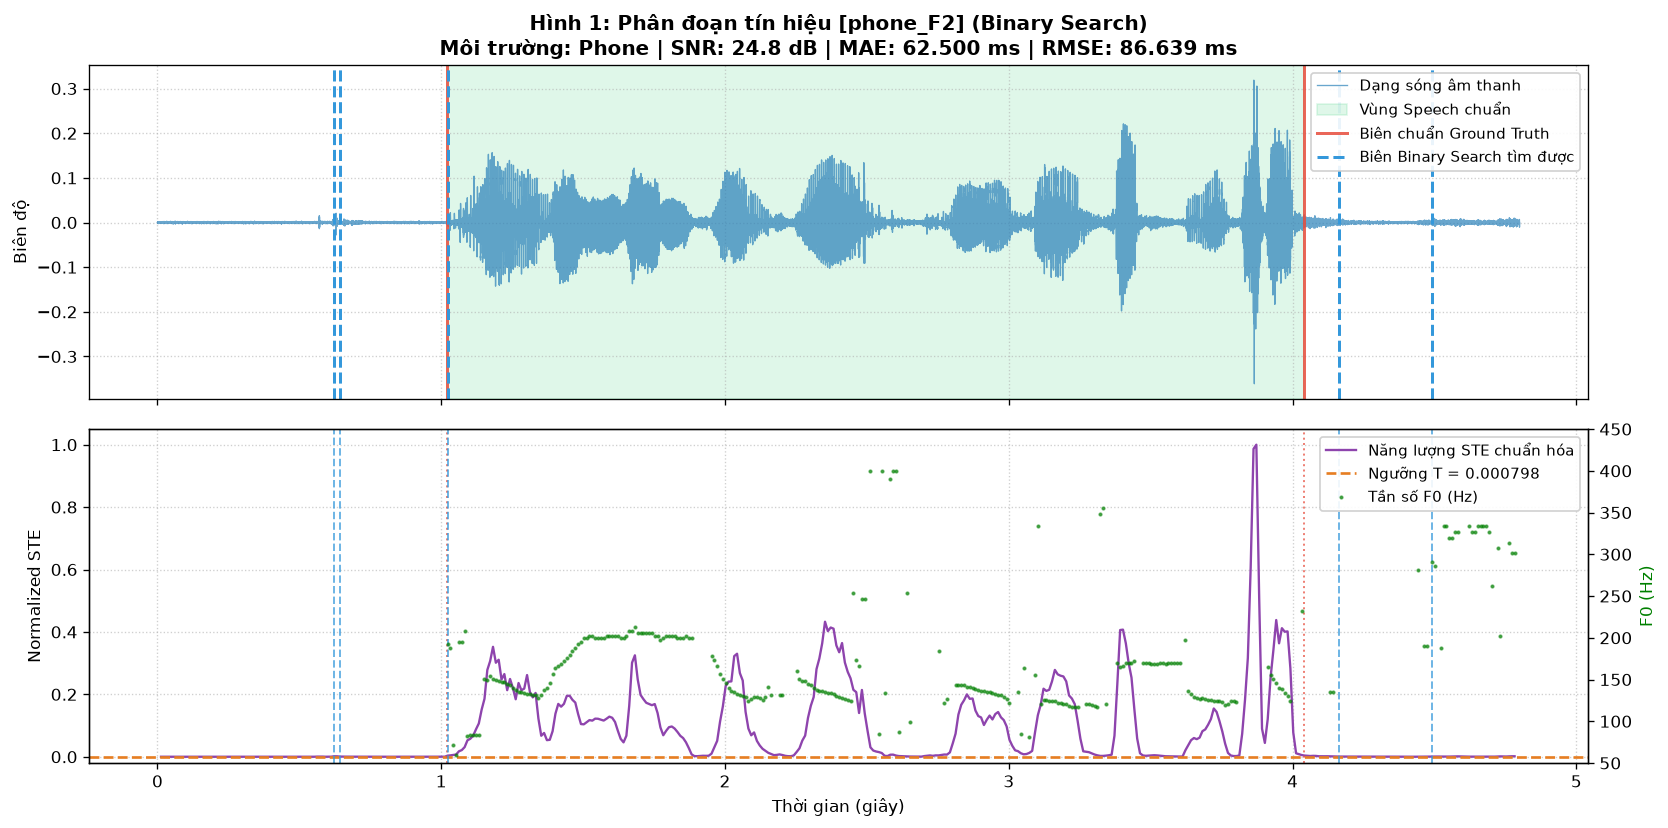

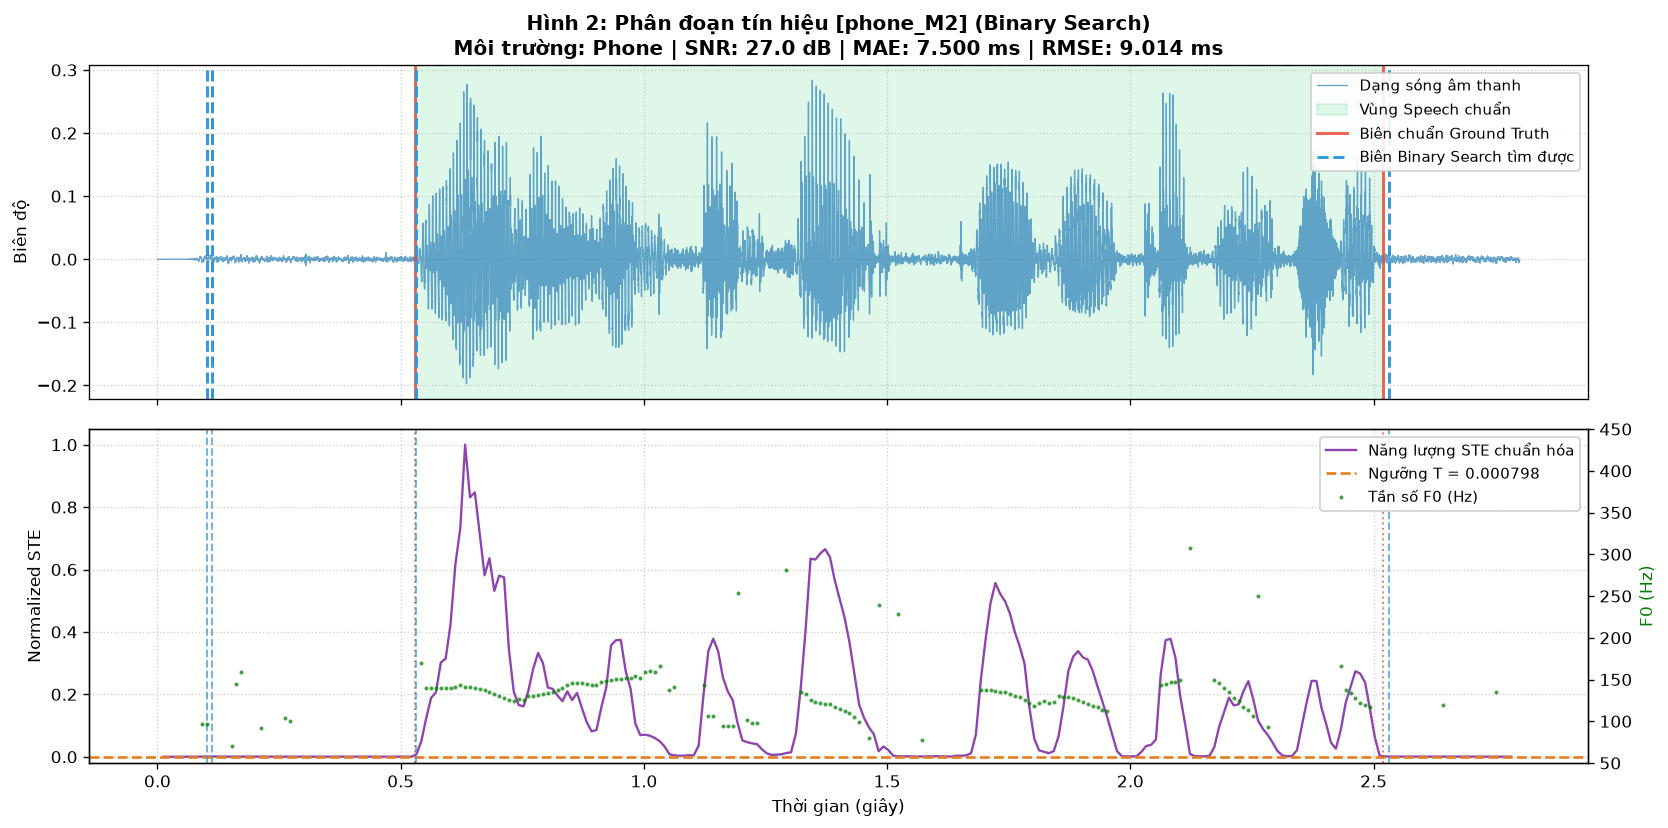

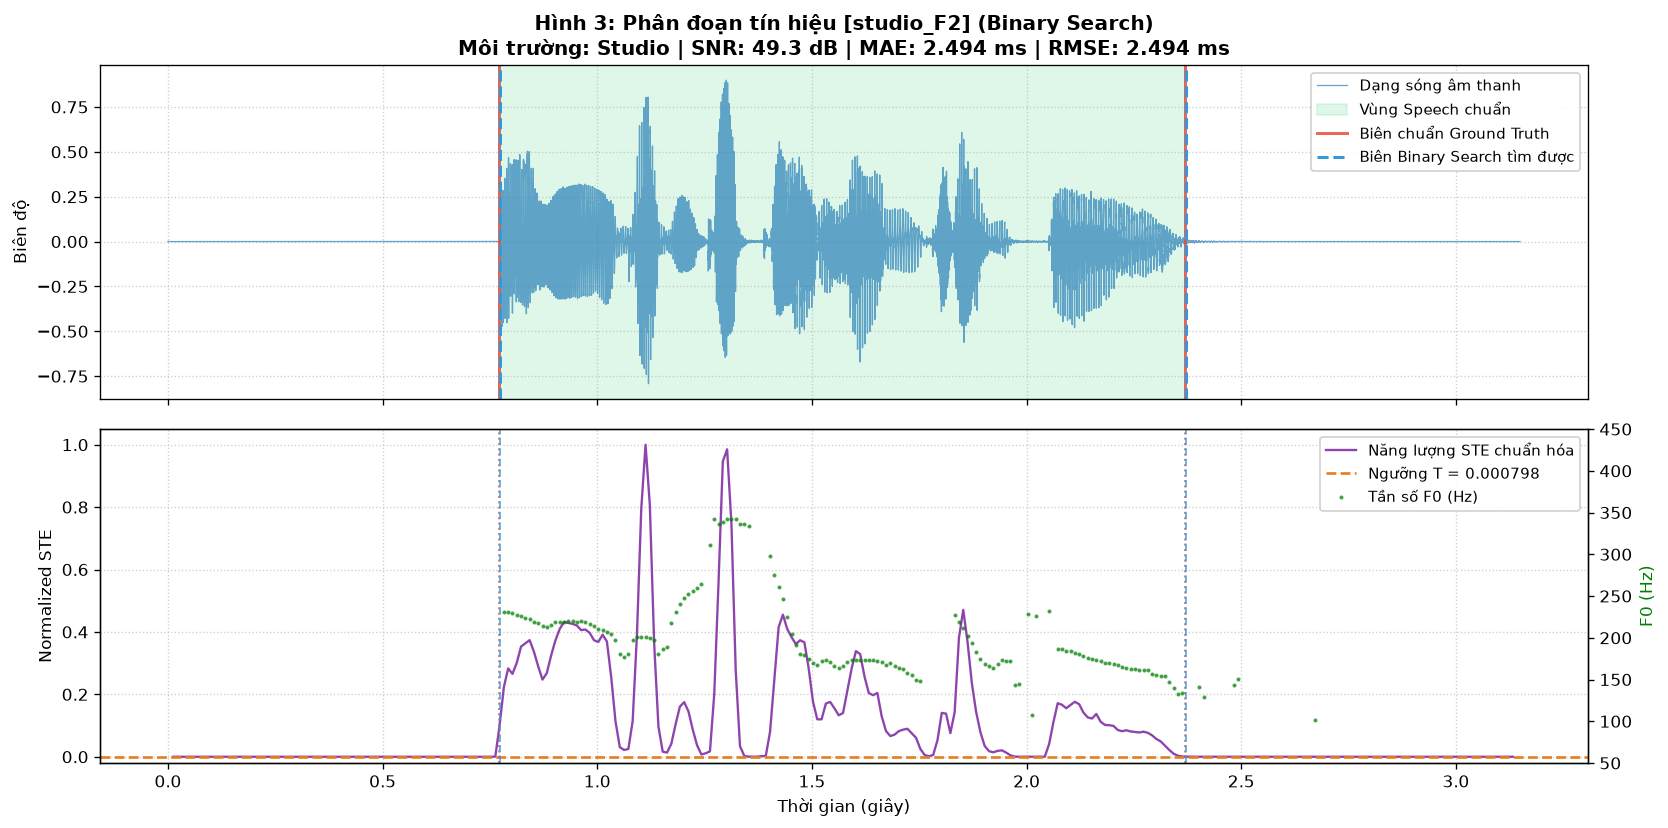

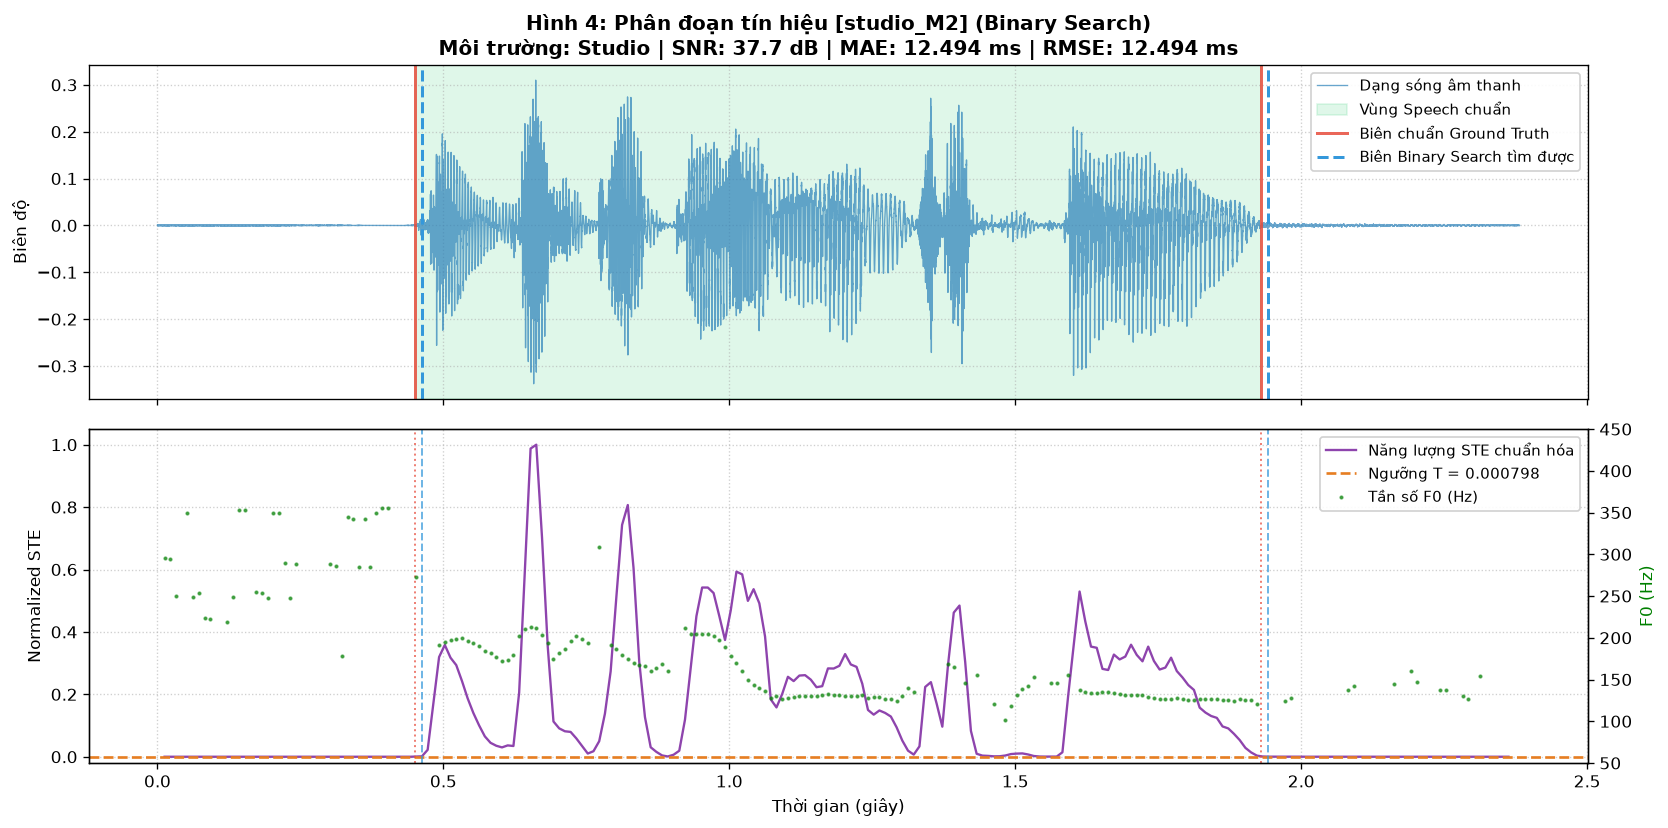

In [8]:
for i, res in enumerate(results_summary, start=1):
    sig = res["sig"]
    timestamps = res["timestamps"]
    ste_norm = res["ste_norm"]
    f0_hz = res["f0_hz"]
    pred_boundaries = res["pred_boundaries"]
    time_axis = np.linspace(0.0, sig.duration_sec, len(sig.signal))

    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 7), sharex=True)

    ax1.plot(time_axis, sig.signal, color="#2980b9", alpha=0.7, linewidth=0.8, label="Dạng sóng âm thanh")
    for j, (start_t, end_t) in enumerate(sig.gt_segments):
        ax1.axvspan(start_t, end_t, color="#2ecc71", alpha=0.15, label="Vùng Speech chuẩn" if j == 0 else "")

    for j, gt_t in enumerate(sig.gt_boundaries):
        ax1.axvline(gt_t, color="#e74c3c", linestyle="-", linewidth=1.8, alpha=0.85, label="Biên chuẩn Ground Truth" if j == 0 else "")

    for j, pred_t in enumerate(pred_boundaries):
        ax1.axvline(pred_t, color="#3498db", linestyle="--", linewidth=1.8, label="Biên Binary Search tìm được" if j == 0 else "")

    ax1.set_title(
        f"Hình {i}: Phân đoạn tín hiệu [{sig.name}] (Binary Search)\n"
        f"Môi trường: {res['env']} | SNR: {res['snr_db']:.1f} dB | MAE: {res['mae_ms']:.3f} ms | RMSE: {res['rmse_ms']:.3f} ms",
        fontsize=12, fontweight="bold"
    )
    ax1.set_ylabel("Biên độ", fontsize=10)
    ax1.grid(True, linestyle=":", alpha=0.6)
    ax1.legend(loc="upper right", framealpha=0.9, fontsize=9)

    ax2.plot(timestamps, ste_norm, color="#8e44ad", linewidth=1.4, label="Năng lượng STE chuẩn hóa")
    ax2.axhline(T_binary, color="#e67e22", linestyle="--", linewidth=1.6, label=f"Ngưỡng T = {T_binary:.6f}")

    for gt_t in sig.gt_boundaries:
        ax2.axvline(gt_t, color="#e74c3c", linestyle=":", linewidth=1.2, alpha=0.7)
    for pred_t in pred_boundaries:
        ax2.axvline(pred_t, color="#3498db", linestyle="--", linewidth=1.2, alpha=0.7)

    ax2.set_ylabel("Normalized STE", fontsize=10)
    ax2.set_xlabel("Thời gian (giây)", fontsize=10)
    ax2.set_ylim(-0.02, 1.05)
    ax2.grid(True, linestyle=":", alpha=0.6)

    ax2_f0 = ax2.twinx()
    valid_f0_mask = ~np.isnan(f0_hz)
    if np.any(valid_f0_mask):
        ax2_f0.plot(timestamps[valid_f0_mask], f0_hz[valid_f0_mask], "g.", markersize=3, alpha=0.6, label="Tần số F0 (Hz)")
        ax2_f0.set_ylabel("F0 (Hz)", color="green", fontsize=10)
        ax2_f0.set_ylim(50, 450)
    else:
        ax2_f0.set_yticks([])

    lines_2, labels_2 = ax2.get_legend_handles_labels()
    lines_f0, labels_f0 = ax2_f0.get_legend_handles_labels()
    ax2.legend(lines_2 + lines_f0, labels_2 + labels_f0, loc="upper right", framealpha=0.9, fontsize=9)

    plt.tight_layout()
    plt.show()
